In [3]:
import numpy as np
from scipy import stats
import math

# fisher exact test for contigency tables
# p_value < alpha (significance level=0.05) reject null hypothesis. Probability distribution under in fisher exact test is hypergeometric(62000,31000,102) under null.

stats.fisher_exact([[39, 63],[30961, 30937]],'less') # where 39 deaths in tratment group and 63 deaths in control group with 31000 in each group at random

# The threshold is x for which ,P(Binomial(31000,0.00203)<x) = alpha( significanace level 0.05), we reject the null hypothesis where 0.00204 is probability of deathsnin control group.. This test is an appreoximation of fischer exact.
#which can be computed using the Python command
print(stats.binom.ppf(0.05, 31000, 0.00203))
# reject null when observed value of x is less than 50

# z test
# We can get the p-value by getting the cdf for the value z=-3.02679296047 where z is z -test statistic that is standard normal distributed. Asuumes normallity of random variable
stats.norm.cdf(-3.02679296047)
# t test for mean which again assumes noemallity for random variable , large sample size uses CLT which gurantes normality. for 10 smaples t test statistic follows t_9 distribution
X = np.array([ 0.9, -0.9, 4.3, 2.9, 1.2, 3. , 2.7, 0.6, 3.6, -0.5]) # Continuing with sleeping drug experiment, we model the difference of hours of sleep between drug and placebo X for each patient using the model where X isthe di 
t_stats,p_value = stats.ttest_1samp(X, popmean=0) # mean zero
p_value=p_value/2 # since python outpots two sided p value
print(p_value)

50.0
0.005560692749284678


In [69]:
# likelihoo ratio test statistic =-2logL(x) where L(x) is likelihood
from scipy.stats import binom
x=-2*math.log(binom.pmf(39,31000,102/62000) *binom.pmf(63,31000,102/62000) / binom.pmf(39,31000,39/31000) * binom.pmf(63,31000,63/31000))

# log likelihood test static approches chi square  distribution as n approches infinity

stats.chi2.sf(x=1.189, df=99) #p_value_log likeligood test statistic

stats.chi2.ppf(1-.05, 99)# calculates mini val of test statistic above which to not reject null.Conversely,stats.chi2.ppf(.05, 99) calculates mini val of test statistic below which to reject  
stats.chi2.isf(.05,99)

123.22522145336181

In [5]:
# Correlation and least square

Xs = np.array([0.0339, 0.0423, 0.213, 0.257, 0.273, 0.273, 0.450, 0.503, 0.503, \
0.637, 0.805, 0.904, 0.904, 0.910, 0.910, 1.02, 1.11, 1.11, 1.41, \
1.72, 2.03, 2.02, 2.02, 2.02])

Ys = np.array([-19.3, 30.4, 38.7, 5.52, -33.1, -77.3, 398.0, 406.0, 436.0, 320.0, 373.0, \
93.9, 210.0, 423.0, 594.0, 829.0, 718.0, 561.0, 608.0, 1.04E3, 1.10E3, \
840.0, 801.0, 519.0])

N = 24

np.mean(Ys);np.mean(Xs)
np.std(Xs, ddof=1)
print(f"Sample standard deviation (using numpy.std with ddof=1): {np.std(Ys, ddof=1)}")
#Explanation of ddof=1:
#When calculating the sample standard deviation, the denominator in the variance formula is n - 1, where n is the number of data points. This is because using n (as in population standard deviation) would underestimate the true population standard deviation when working with a sample. The ddof=1 parameter in numpy.std() ensures this n - 1 correction is applied.


Sample standard deviation (using numpy.std with ddof=1): 348.7336574977229


In [6]:
covariance_matrix = np.cov(Xs, Ys)

print("Covariance Matrix:")
print(covariance_matrix)

sample_covariance_xy = covariance_matrix[0, 1]
print(f"\nSample Covariance between x and y: {sample_covariance_xy}")

Covariance Matrix:
[[4.26924798e-01 1.91207065e+02]
 [1.91207065e+02 1.21615164e+05]]

Sample Covariance between x and y: 191.20706528260865


In [7]:
correlation_matrix = np.corrcoef(Xs, Ys)

# The Pearson correlation coefficient between x and y is found at [0, 1] or [1, 0]
sample_correlation_coefficient = correlation_matrix[0, 1]

print(f"Sample Correlation Coefficient (NumPy): {sample_correlation_coefficient}")


Sample Correlation Coefficient (NumPy): 0.8391399162310661


In [8]:
# slope os a linear regression
slope=sample_correlation_coefficient*np.std(Ys, ddof=1)/np.std(Xs, ddof=1)

In [9]:
#intercept
np.mean(Ys)-(np.mean(Xs)*slope)

13.610139085217213

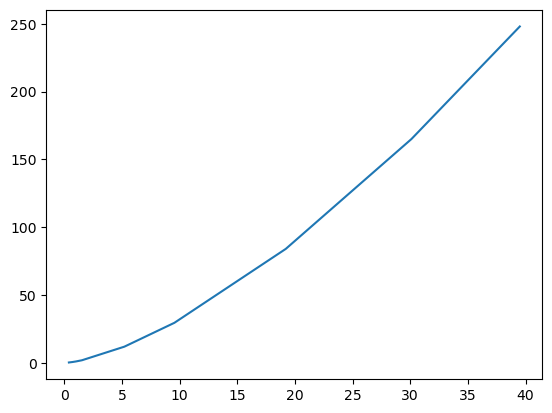

0.9888323018726733


In [10]:
# raw data
Xs = np.array([ 0.387, 0.723, 1.00, 1.52, 5.20, 9.54, 19.2, 30.1, 39.5 ])

Ys = np.array([ 0.241, 0.615, 1.00, 1.88, 11.9, 29.5, 84.0, 165.0, 248 ])

N = 9

import matplotlib.pyplot as plt
plt.plot(Xs,Ys)
plt.show()

correlation_matrix = np.corrcoef(Xs, Ys)

# The Pearson correlation coefficient between x and y is found at [0, 1] or [1, 0]
sample_correlation_coefficient = correlation_matrix[0, 1]
print(sample_correlation_coefficient)

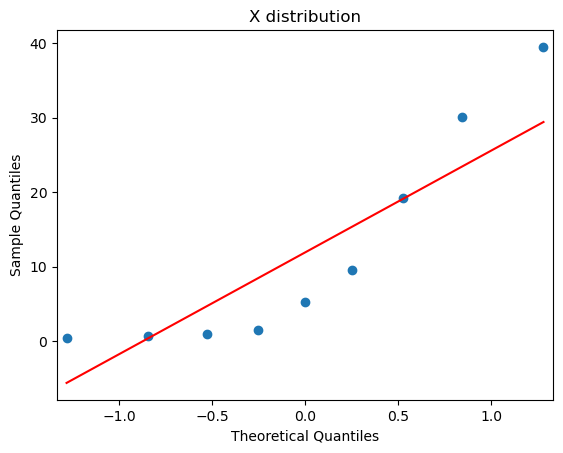

In [11]:
# Q-Q plot : Recall that the Q-Q plot compares the empirical distribution of the data to a theoretical normal distribution by comparing the empirical quantiles to the corresponding theoretical quantiles. If the empirical and theoretical distributions are the same, the data points on the plot will fall onto a  line. In the above example, the line='s' option scales this line by the empirical mean and standard deviation.
import statsmodels.api as sm
sm.qqplot(Xs, line='s')
plt.title("X distribution")
plt.show()

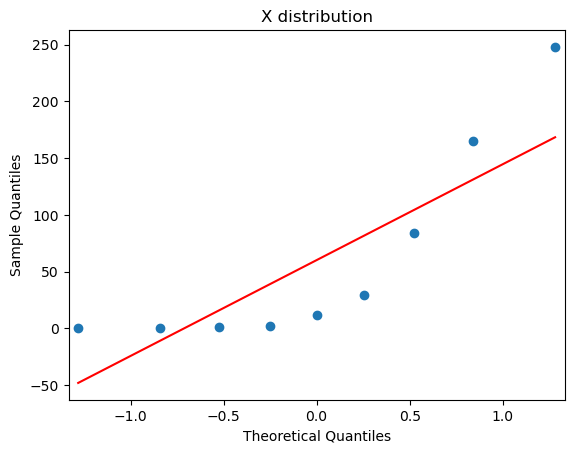

In [12]:
sm.qqplot(Ys, line='s')
plt.title("X distribution")
plt.show()

[-1.42295835 -0.48613301  0.          0.63127178  2.4765384   3.38439026
  4.4308168   5.10594547  5.51342875]
0.9999998085102114
1.4995325773381893


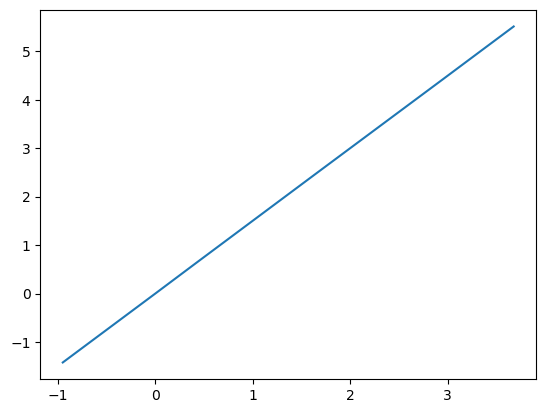

In [13]:
Ys_tranformed=np.log(Ys)
Xs_tranformed=np.log(Xs)
print(Ys_tranformed)
plt.plot(Xs_tranformed,Ys_tranformed)

correlation_matrix = np.corrcoef(Xs_tranformed, Ys_tranformed)

# The Pearson correlation coefficient between x and y is found at [0, 1] or [1, 0]
sample_correlation_coefficient = correlation_matrix[0, 1]
print(sample_correlation_coefficient)

slope=sample_correlation_coefficient*np.std(Ys_tranformed, ddof=1)/np.std(Xs_tranformed, ddof=1)
print(slope)

In [14]:
# raw data : For this exercise, we will perform multiple linear regression on some exoplanetary data to see if we can find a relationship that can predict the mass of an exoplanet.
LogPlanetMass = np.array([-0.31471074,  1.01160091,  0.58778666,  0.46373402, -0.01005034,
         0.66577598, -1.30933332, -0.37106368, -0.40047757, -0.27443685,
         1.30833282, -0.46840491, -1.91054301,  0.16551444,  0.78845736,
        -2.43041846,  0.21511138,  2.29253476, -2.05330607, -0.43078292,
        -4.98204784, -0.48776035, -1.69298258, -0.08664781, -2.28278247,
         3.30431931, -3.27016912,  1.14644962, -3.10109279, -0.61248928])

LogPlanetRadius = np.array([ 0.32497786,  0.34712953,  0.14842001,  0.45742485,  0.1889661 ,
         0.06952606,  0.07696104,  0.3220835 ,  0.42918163, -0.05762911,
         0.40546511,  0.19227189, -0.16251893,  0.45107562,  0.3825376 ,
        -0.82098055,  0.10436002,  0.0295588 , -1.17921515,  0.55961579,
        -2.49253568,  0.11243543, -0.72037861,  0.36464311, -0.46203546,
         0.13976194, -2.70306266,  0.12221763, -2.41374014,  0.35627486])

LogPlanetOrbit = np.array([-2.63108916, -3.89026151, -3.13752628, -2.99633245, -3.12356565,
        -2.33924908, -2.8507665 , -3.04765735, -2.84043939, -3.19004544,
        -3.14655516, -3.13729584, -3.09887303, -3.09004295, -3.16296819,
        -2.3227878 , -3.77661837, -2.52572864, -4.13641734, -3.05018846,
        -2.40141145, -3.14795149, -0.40361682, -3.2148838 , -2.74575207,
        -3.70014265, -1.98923527, -3.35440922, -1.96897409, -2.99773428])

StarMetallicity = np.array([ 0.11 , -0.002, -0.4  ,  0.01 ,  0.15 ,  0.22 , -0.01 ,  0.02 ,
        -0.06 , -0.127,  0.   ,  0.12 ,  0.27 ,  0.09 , -0.077,  0.3  ,
         0.14 , -0.07 ,  0.19 , -0.02 ,  0.12 ,  0.251,  0.07 ,  0.16 ,
         0.19 ,  0.052, -0.32 ,  0.258,  0.02 , -0.17 ])

LogStarMass = np.array([ 0.27002714,  0.19144646, -0.16369609,  0.44468582,  0.19227189,
         0.01291623,  0.0861777 ,  0.1380213 ,  0.49469624, -0.43850496,
         0.54232429,  0.02469261,  0.07325046,  0.42133846,  0.2592826 ,
        -0.09431068, -0.24846136, -0.12783337, -0.07364654,  0.26159474,
         0.07603469, -0.07796154,  0.09440068,  0.07510747,  0.17395331,
         0.28893129, -0.21940057,  0.02566775, -0.09211529,  0.16551444])

LogStarAge = np.array([ 1.58103844,  1.06471074,  2.39789527,  0.72754861,  0.55675456,
         1.91692261,  1.64865863,  1.38629436,  0.77472717,  1.36097655,
         0.        ,  1.80828877,  1.7837273 ,  0.64185389,  0.69813472,
         2.39789527, -0.35667494,  1.79175947,  1.90210753,  1.39624469,
         1.84054963,  2.19722458,  1.89761986,  1.84054963,  0.74193734,
         0.55961579,  1.79175947,  0.91629073,  2.17475172,  1.36097655])

N = 30
# However, in astronomy and physics, it is very common for the predicted variable to be multiplicative in the predictors.
#For example, the power that a solar cell produces is the product of the amount of solar radiation and the efficiency of the cell.
#In that case, it is better to transform the variables by taking the logarithm as discussed previously.

# transform data into matrix representation

X=np.hstack([LogPlanetRadius.reshape(-1,1),LogPlanetOrbit.reshape(-1,1),StarMetallicity.reshape(-1,1),LogStarMass.reshape(-1,1),LogStarAge.reshape(-1,1)])
ones_column = np.ones((X.shape[0], 1))
X_new= np.hstack((ones_column,X))
Y=LogPlanetMass.reshape(-1,1) # column vector for y
print(X_new)
print(Y.shape)
#  y=beta*X beta least square estimate

beta = np.dot(np.dot(np.linalg.inv(np.dot(np.transpose(X_new), X_new)), np.transpose(X_new)), Y)
print(beta)

[[ 1.00000000e+00  3.24977860e-01 -2.63108916e+00  1.10000000e-01
   2.70027140e-01  1.58103844e+00]
 [ 1.00000000e+00  3.47129530e-01 -3.89026151e+00 -2.00000000e-03
   1.91446460e-01  1.06471074e+00]
 [ 1.00000000e+00  1.48420010e-01 -3.13752628e+00 -4.00000000e-01
  -1.63696090e-01  2.39789527e+00]
 [ 1.00000000e+00  4.57424850e-01 -2.99633245e+00  1.00000000e-02
   4.44685820e-01  7.27548610e-01]
 [ 1.00000000e+00  1.88966100e-01 -3.12356565e+00  1.50000000e-01
   1.92271890e-01  5.56754560e-01]
 [ 1.00000000e+00  6.95260600e-02 -2.33924908e+00  2.20000000e-01
   1.29162300e-02  1.91692261e+00]
 [ 1.00000000e+00  7.69610400e-02 -2.85076650e+00 -1.00000000e-02
   8.61777000e-02  1.64865863e+00]
 [ 1.00000000e+00  3.22083500e-01 -3.04765735e+00  2.00000000e-02
   1.38021300e-01  1.38629436e+00]
 [ 1.00000000e+00  4.29181630e-01 -2.84043939e+00 -6.00000000e-02
   4.94696240e-01  7.74727170e-01]
 [ 1.00000000e+00 -5.76291100e-02 -3.19004544e+00 -1.27000000e-01
  -4.38504960e-01  1.3609

In [15]:
# t test for parameter when number of parameters are more than number of datapoints p >N.
#Will have to regularize the parametrs using lasso penalty to parameters and secting the import features only( Model selection and regularization). Backward seclection using itertaive t test

In [23]:
import pandas as pd
csv_file=pd.read_csv("gamma-ray.csv")

In [24]:
csv_file.head()

,seconds,count
0,116.0,0.0
1,112.0,0.0
2,160.0,0.0
3,51.5,0.0
4,102.0,1.0


In [25]:
csv_file["count"].mean()

0.61

In [27]:
# multiple hypothessis testing 
import zipfile
with zipfile.ZipFile("release_statsreview_release1.zip") as zip_file:
    golub_data, golub_classnames = ( np.genfromtxt(zip_file.open('data_and_materials/golub_data/{}'.format(fname)), delimiter=',', names=True, converters={0: lambda s: int(s.strip(b'"'))}) for fname in ['golub.csv', 'golub_cl.csv'] )
#This extracts data as list of tuples
#print(golub_data)
# one can also use pandas to extract csv data directly
file=pd.read_csv("golub.csv")
print(file.head())
# t welch test for difference in mean of two population

p_values=[]

for i in range(file.shape[0]):
# Perform Welch's t-test by setting equal_var=False for Sample data for two groups file.iloc[i,1:29] and file.iloc[i,29:39]
    t_statistic, p_value = stats.ttest_ind(file.iloc[i,1:28], file.iloc[i,28:39], equal_var=False)
    p_values.append(p_value)

print(f"Length of uncorelated p values vector for 3051 genes: {len(p_values)}")


count = len([x for x in p_values if x <= 0.05])


# Interpret the results
alpha = 0.05
print(f"Nof genes with significant difference between the two groups: {count}")

#Now, find the number of significantly associated genes using the Holm-Bonferroni and Benjamini-Hochberg corrections to the p-values.Results in Correct for no of false significants out of all significants tests(BH) or all tests where null is actually true(HB).
#How many genes are significant according to the Holm-Bonferroni corrected p-values
import statsmodels.stats.multitest as smm
results= smm.multipletests(p_values, alpha=0.05, method='holm')
reject = results[0]
pvals_corrected = results[1]
print(pvals_corrected, np.sum(reject))

# How many genes are significant according to the Benjamini-Hochberg corrected p-values
results= smm.multipletests(p_values, alpha=0.05, method='fdr_bh')
reject = results[0]
pvals_corrected = results[1]
print(pvals_corrected, np.sum(reject))

   Unnamed: 0       V1       V2       V3       V4       V5       V6       V7  \
0           1 -1.45769 -1.39420 -1.42779 -1.40715 -1.42668 -1.21719 -1.37386   
1           2 -0.75161 -1.26278 -0.09052 -0.99596 -1.24245 -0.69242 -1.37386   
2           3  0.45695 -0.09654  0.90325 -0.07194  0.03232  0.09713 -0.11978   
3           4  3.13533  0.21415  2.08754  2.23467  0.93811  2.24089  3.36576   
4           5  2.76569 -1.27045  1.60433  1.53182  1.63728  1.85697  3.01847   

        V8       V9  ...      V29      V30      V31      V32      V33  \
0 -1.36832 -1.47649  ... -1.08902 -1.29865 -1.26183 -1.44434  1.10147   
1 -0.50803 -1.04533  ... -1.08902 -1.05094 -1.26183 -1.25918  0.97813   
2  0.23381  0.23987  ... -0.43377 -0.10823 -0.29385  0.05067  1.69430   
3  1.97859  2.66468  ...  0.29598 -1.29865  2.76869  2.08960  0.70003   
4  1.12853  2.17016  ... -1.08902 -1.29865  2.00518  1.17454 -1.47218   

       V34      V35      V36      V37      V38  
0 -1.34158 -1.22961 -0.75919  0

In [47]:
# Load data
def read_mortality_csv(zip_file):
  import io
  import csv
  fields, cities, values = None, [], []
  with io.TextIOWrapper(zip_file.open('data_and_materials/mortality.csv')) as wrap:
    csv_reader = csv.reader(wrap, delimiter=',', quotechar='"')
    fields = next(csv_reader)[1:]
    for row in csv_reader:
      cities.append(row[0])
      values.append(tuple(map(float, row[1:])))
  dtype = np.dtype([(name, float) for name in fields])
  return cities, fields, np.array(values, dtype=dtype).view(np.recarray)

with zipfile.ZipFile("release_statsreview_release1.zip") as zip_file:
  syn_X, syn_y = ( np.loadtxt(zip_file.open('data_and_materials/{}'.format(fname)), delimiter=',') for fname in ['syn_X.csv', 'syn_y.csv'] )
  m_cities, m_fields, m_values = read_mortality_csv(zip_file)

In [45]:
# transform data into matrix representation
#Now apply OLS estimator formula to the synthetic data matrix and data vector to compute the OLS estimator. Remember to add a column of ones to X
X=pd.read_csv("syn_X.csv",header=None)
y=pd.read_csv("syn_y.csv",header=None)
print(X.head())
print(y.head())
X_matrix=X.to_numpy()
y_vector=y.to_numpy()
ones_column = np.ones((X_matrix.shape[0], 1))
X_new= np.hstack((ones_column,X_matrix))

print(X_new)

#  y=beta*X beta least square estimate

beta = np.dot(np.dot(np.linalg.inv(np.dot(np.transpose(X_new), X_new)), np.transpose(X_new)), y_vector)
print(beta)


# alternative implementation os the same scheme

def add_intercept(X):
  return np.concatenate((np.ones_like(X[:,:1]), X), axis=1)

def matrix_inverse_OLS(X, y):
  return linalg.inv(X.T.dot(X)).dot(X.T.dot(y))

import numpy.linalg as linalg
beta_hat = matrix_inverse_OLS(add_intercept(syn_X), syn_y)
print(beta_hat)

         0        1
0  0.53767  0.84038
1  1.83390 -0.88803
2 -2.25880  0.10009
3  0.86217 -0.54453
4  0.31877  0.30352
         0
0 -1.04490
1  7.68190
2 -0.68642
3  5.63850
4  1.08430
[[ 1.         0.53767    0.84038  ]
 [ 1.         1.8339    -0.88803  ]
 [ 1.        -2.2588     0.10009  ]
 [ 1.         0.86217   -0.54453  ]
 [ 1.         0.31877    0.30352  ]
 [ 1.        -1.3077    -0.60033  ]
 [ 1.        -0.43359    0.48997  ]
 [ 1.         0.34262    0.73936  ]
 [ 1.         3.5784     1.7119   ]
 [ 1.         2.7694    -0.19412  ]
 [ 1.        -1.3499    -2.1384   ]
 [ 1.         3.0349    -0.83959  ]
 [ 1.         0.7254     1.3546   ]
 [ 1.        -0.063055  -1.0722   ]
 [ 1.         0.71474    0.96095  ]
 [ 1.        -0.20497    0.12405  ]
 [ 1.        -0.12414    1.4367   ]
 [ 1.         1.4897    -1.9609   ]
 [ 1.         1.409     -0.1977   ]
 [ 1.         1.4172    -1.2078   ]
 [ 1.         0.6715     2.908    ]
 [ 1.        -1.2075     0.82522  ]
 [ 1.         0.71724 

In [29]:
# Here's a Python implementation of gradient descent for the least squares problem, including a function signature and a method to find the optimal step size

def gradient_descent(X, y, step_size, precision=1e-6, max_iterations=10000):
    """
    Implements gradient descent for the least squares problem.

    Args:
        X (np.ndarray): Feature matrix (n_samples, n_features).
        y (np.ndarray): Target vector (n_samples,).
        step_size (float): Learning rate for gradient descent.
        precision (float): Relative precision for termination condition.
        max_iterations (int): Maximum number of iterations to prevent infinite loops.

    Returns:
        tuple: A tuple containing:
            - beta (np.ndarray): The learned coefficients.
            - iterations (int): The number of iterations taken to converge.
    """
    n_samples, n_features = X.shape
    beta =np.array([0.01,0.01,0.01])  # Initial starting beta of all zeros
    beta=beta.reshape(-1,1)

    for i in range(max_iterations):
        y_pred = X @ beta
        gradient = -2 * X.T @ (y - y_pred) / n_samples  # Gradient of MSE
        
        beta_new = beta - step_size * gradient
        
        # Termination condition: relative precision for beta

        if np.linalg.norm(beta_new - beta) / np.linalg.norm(beta) < precision:
            return beta_new, i + 1
        
        beta = beta_new
        
    return beta, max_iterations # Return if max_iterations reached

# Try different step sizes to find the optimal one
step_sizes = [0.5]
optimal_step_size = None
min_iterations = float('inf')

print("Testing different step sizes:")
for ss in step_sizes:
    beta_learned, iterations = gradient_descent(X_new, y_vector, step_size=ss)
    print(f"Step size: {ss}, Iterations: {iterations}")
    if iterations < min_iterations:
        min_iterations = iterations
        optimal_step_size = ss

print(f"\nOptimal step size found: {optimal_step_size} (converged in {min_iterations} iterations)")

# Run with the optimal step size
optimal_beta, optimal_iterations = gradient_descent(X_new, y_vector, optimal_step_size)

print("\nResults with optimal step size:")
print(f"Learned beta: {optimal_beta}")
print(f"Iterations for optimal step size: {optimal_iterations}")

Testing different step sizes:
Step size: 0.5, Iterations: 15

Optimal step size found: 0.5 (converged in 15 iterations)

Results with optimal step size:
Learned beta: [[ 1.92960632]
 [ 1.26397201]
 [-4.59799315]]
Iterations for optimal step size: 15


In [49]:
# Define gradient desent more systematically and detailed

def loss_fn(beta, X, y):
  # (y - X beta)^T (y - X beta)
  return np.sum(np.square(y - X.dot(beta)))

def loss_grad(beta, X, y):
  # -2*(y - X beta)^T X
  return -2*(y - X.dot(beta)).T.dot(X)

def gradient_step(beta, step_size, X, y):
  loss, grads = loss_fn(beta, X, y), loss_grad(beta, X, y)
  # beta_(i+1) = beta_i - alpha (del f)^T
  beta = beta - step_size * grads.T
  return loss, beta

def gradient_descent(X, y, step_size, precision, max_iter=10000, warn_max_iter=True):
  beta = np.zeros_like(X[0])
  # beta = np.random.randn(len(X[0]))

  losses = [] # Array for recording the value of the loss over the iterations.
  graceful = False
  for _ in range(max_iter):
    beta_last = beta # Save last values of beta for later stopping criterion
    loss, beta = gradient_step(beta, step_size, X, y)
    losses.append(loss)
    # Use the norm of the difference between the new beta and the old beta as a stopping criteria
    if np.sqrt(np.sum(np.square((beta - beta_last)/beta))) < precision:
      graceful = True
      break
  if not graceful and warn_max_iter:
    print("Reached max iterations.")
  return beta, np.array(losses)


BetaHat = [ 1.92960603  1.26397096 -4.5979933 ]


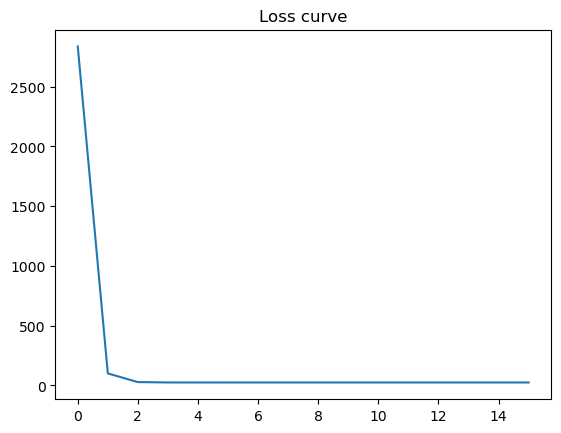

Optimal step size is 0.0042000000000000015 with 11.0 steps


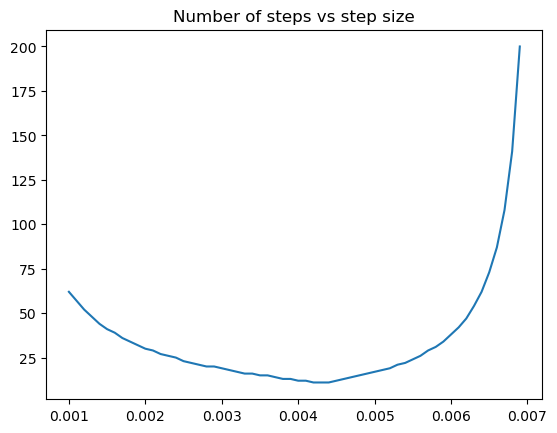

In [51]:
# In author experimentation, it seems a step size of 0.004 converges the fastest
beta_gd, losses = gradient_descent(add_intercept(syn_X), syn_y, 0.004, 1e-8)
print("BetaHat = {}".format(beta_gd))
plt.plot(range(len(losses)), losses)
plt.title("Loss curve")
plt.show()
# Now run a scan over the step size in order to confirm this
step_size_scan_range = np.arange(0.001, 0.007, 0.0001)
step_scan = np.array([ (step_size, len(gradient_descent(add_intercept(syn_X), syn_y, step_size, 1e-6, warn_max_iter=False)[1])) for step_size in step_size_scan_range ]).T # (Feb 17) updated to include intercept feature in scanning the optimal step size
print("Optimal step size is {} with {} steps".format(*step_scan[:, np.argmin(step_scan[1])]))
plt.plot(step_scan[0], step_scan[1])
plt.title("Number of steps vs step size")
plt.show()

C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_25536\319728712.py:5: RuntimeWarning: overflow encountered in square
  return np.sum(np.square(y - X.dot(beta)))
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_25536\319728712.py:9: RuntimeWarning: overflow encountered in multiply
  return -2*(y - X.dot(beta)).T.dot(X)
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_25536\319728712.py:28: RuntimeWarning: invalid value encountered in divide
  if np.sqrt(np.sum(np.square((beta - beta_last)/beta))) < precision:
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_25536\319728712.py:14: RuntimeWarning: invalid value encountered in subtract
  beta = beta - step_size * grads.T


Reached max iterations.
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
nan


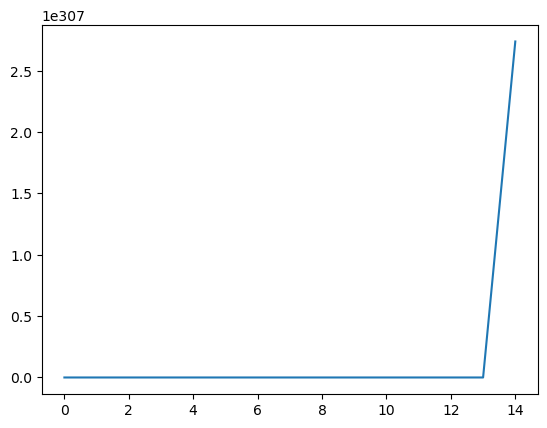

In [53]:
m_y = m_values.Mortality
m_X = np.array([ m_values[f] for f in m_fields if f != 'Mortality']).T # Arrange our X matrix in the same order as the data set, but without the Mortality column.
# Then run the gradient descent, notice the many overflow warnings and the result is all NaNs
m_beta_gd, m_losses = gradient_descent(add_intercept(m_X), m_y, 0.0001, 1e-6, max_iter=100000)
print(m_beta_gd)
print(m_losses[-1])
plt.plot(range(len(m_losses)), m_losses)
plt.show()

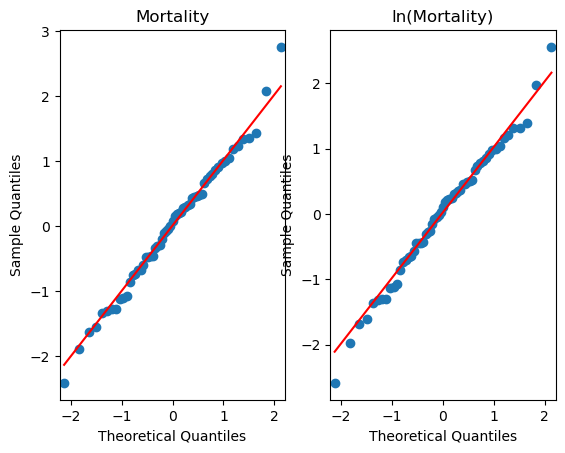

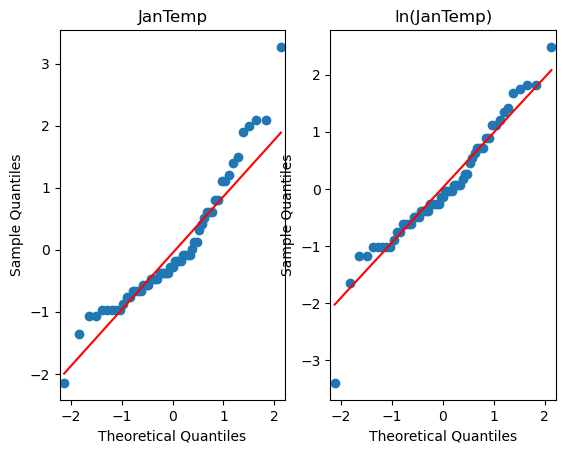

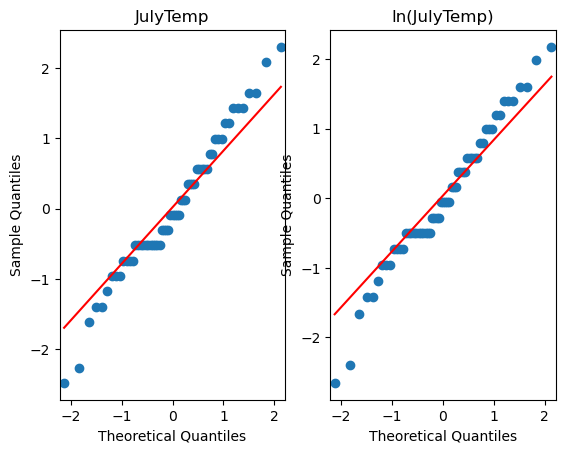

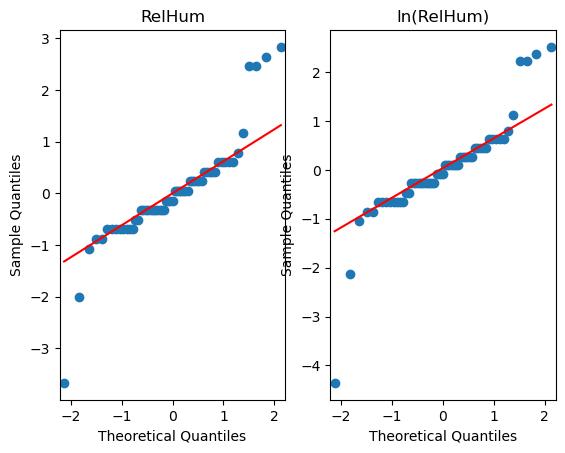

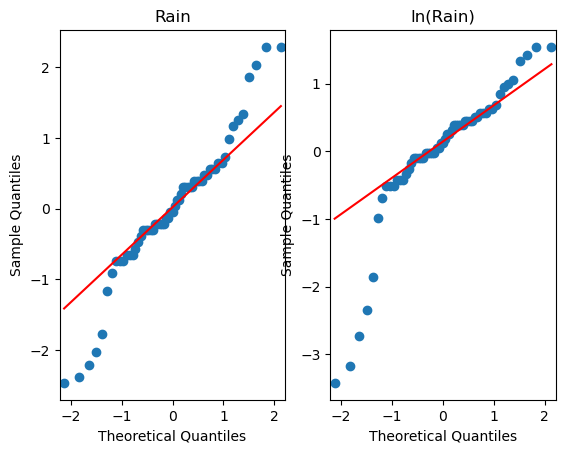

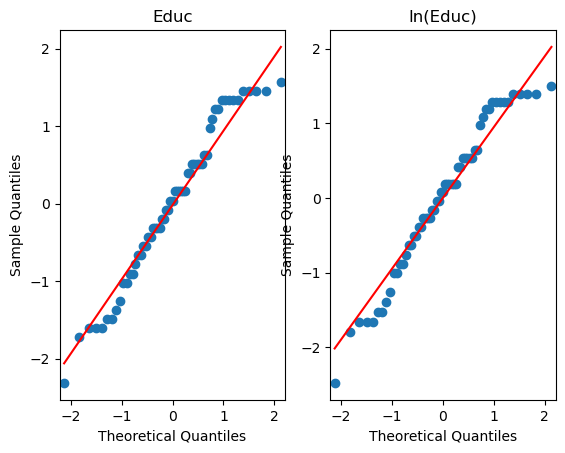

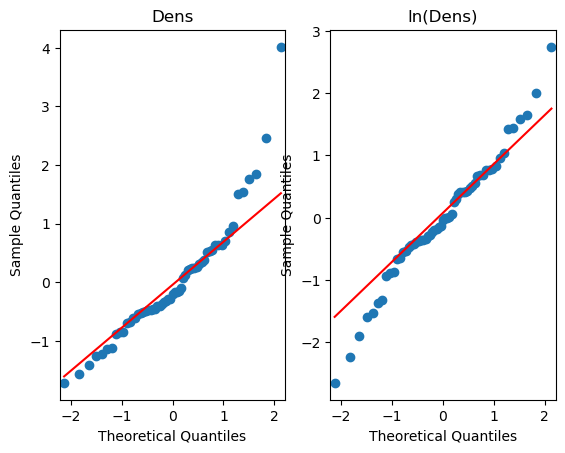

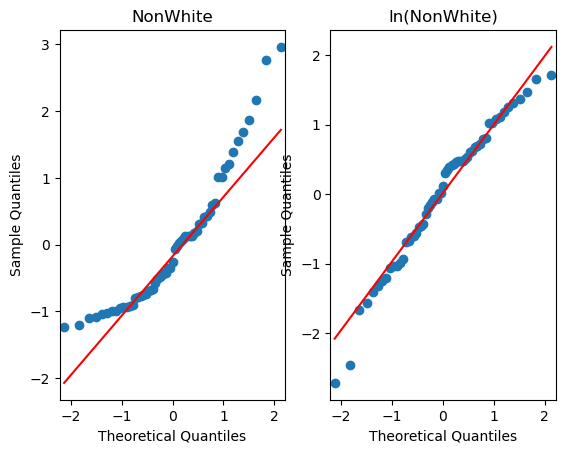

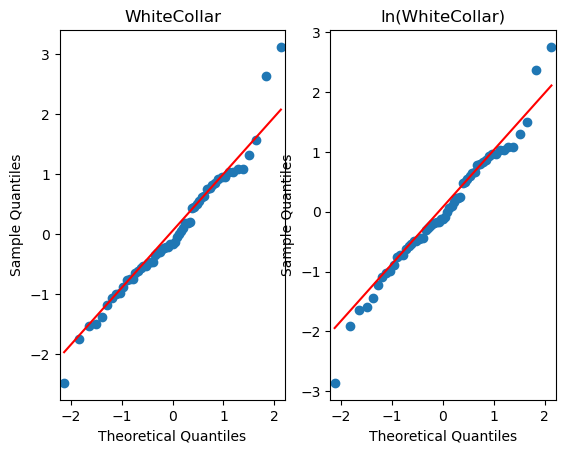

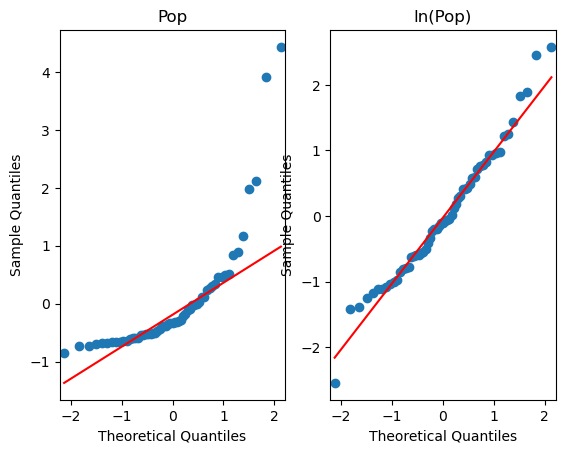

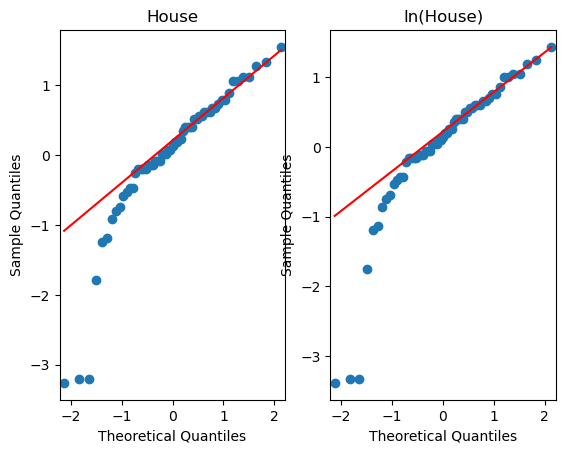

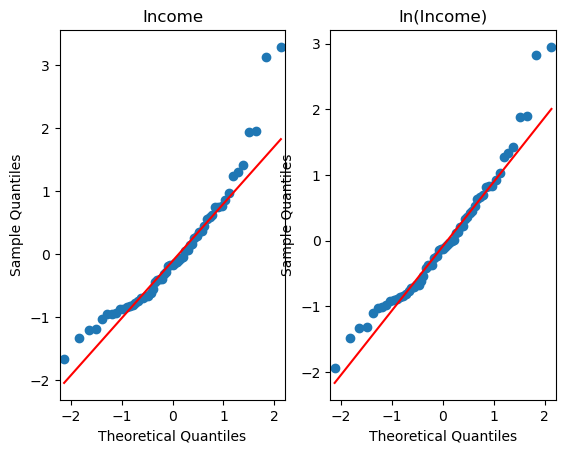

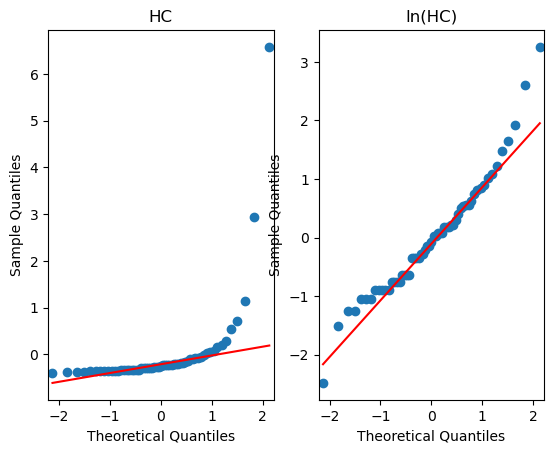

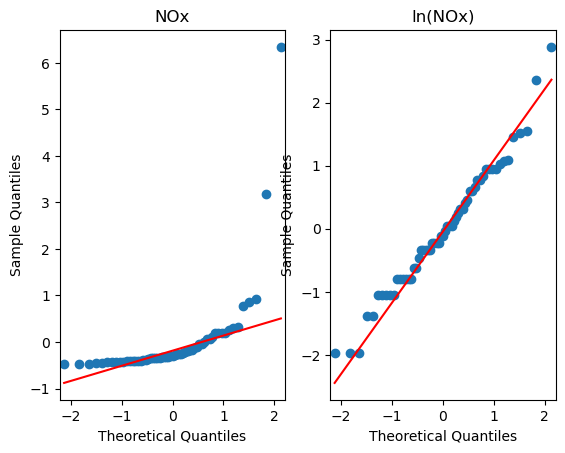

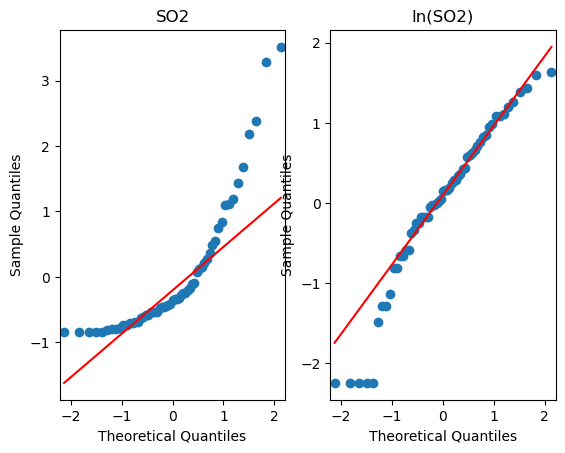

In [55]:
import statsmodels.api as sm
# Here we will make a matrix of Q-Q plots for easy comparison.
for f in m_fields:
  fig = sm.qqplot((m_values[f] - np.mean(m_values[f]))/np.std(m_values[f],ddof = 1), line='q', ax=plt.subplot(1, 2, 1))
  plt.title(f)
  fig = sm.qqplot( (np.log(m_values[f]) -np.mean(np.log(m_values[f]))) / np.std(np.log(m_values[f]), ddof = 1), line='q', ax=plt.subplot(1, 2, 2))
  plt.title("ln({})".format(f))
  plt.show()
# The first thing we can notice from this is the very wide range of values that some variables take

BetaHat = [-3.18522986e-16 -2.34383137e-01 -2.17493726e-01  1.17209807e-02
  1.79782570e-01 -1.50536069e-01  1.08944126e-01  7.64354059e-01
 -1.21215224e-01  8.40236759e-02 -1.11470057e-01 -3.04636391e-02
 -9.95564857e-01  8.80410437e-01  8.62048932e-02]
Final loss value = 13.809259458040312


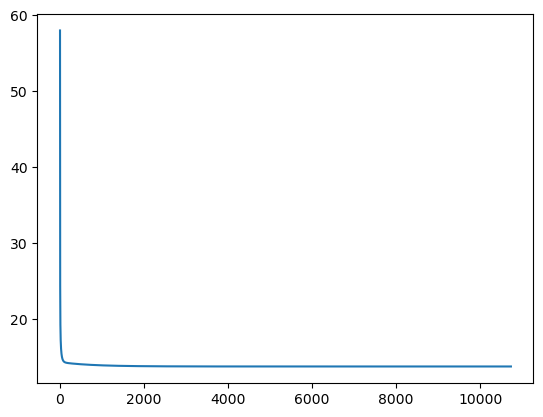

Matrix inverse BetaHat = [-3.42188695e-16 -2.34377091e-01 -2.17496828e-01  1.17238925e-02
  1.79754504e-01 -1.50544513e-01  1.08945825e-01  7.64348559e-01
 -1.21202349e-01  8.40325965e-02 -1.11479218e-01 -3.04687337e-02
 -9.96190618e-01  8.81043305e-01  8.61146149e-02]


In [57]:
# To combat this, we scale these values by their mean and standard deviation.
# Note we also do this for y
m_X_scaled = (m_X - m_X.mean(axis=0))/m_X.std(axis=0, ddof=1)
m_Y_scaled = (m_y - m_y.mean())/m_y.std(ddof=1)
m_X_inter = add_intercept(m_X_scaled)
# Running gradient descent now works.
m_beta_gd, m_losses = gradient_descent(m_X_inter, m_Y_scaled, 0.001, 1e-6, max_iter=100000)
print("BetaHat = {}".format(m_beta_gd))
print("Final loss value = {}".format(m_losses[-1]))
plt.plot(range(len(m_losses)), m_losses)
plt.show()
# As a sanity check, we can also do the matrix inversion 
print("Matrix inverse BetaHat = {}".format(matrix_inverse_OLS(m_X_inter, m_Y_scaled)))

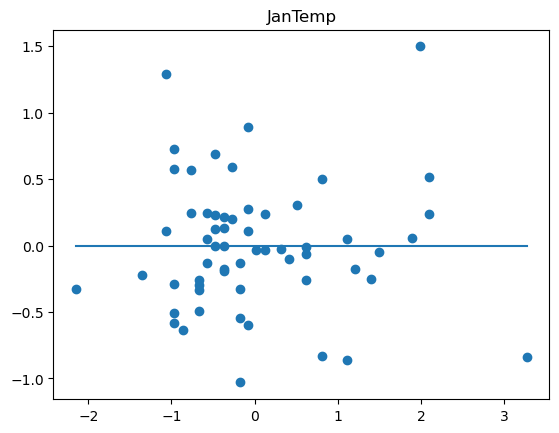

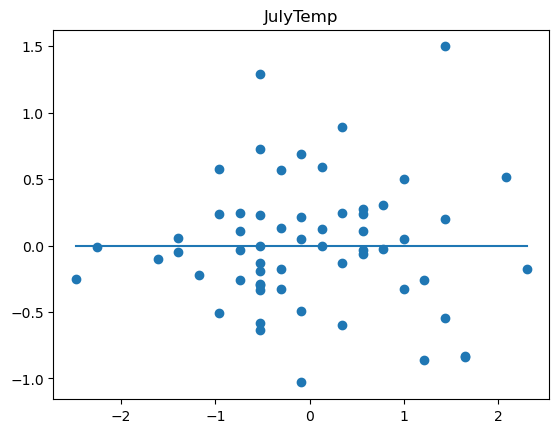

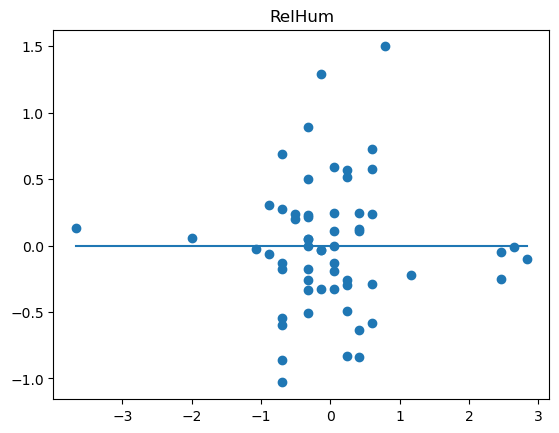

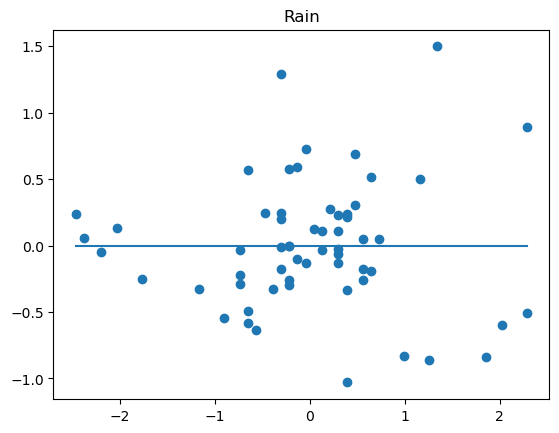

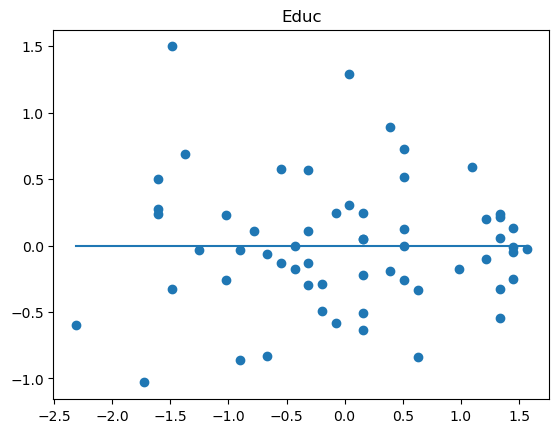

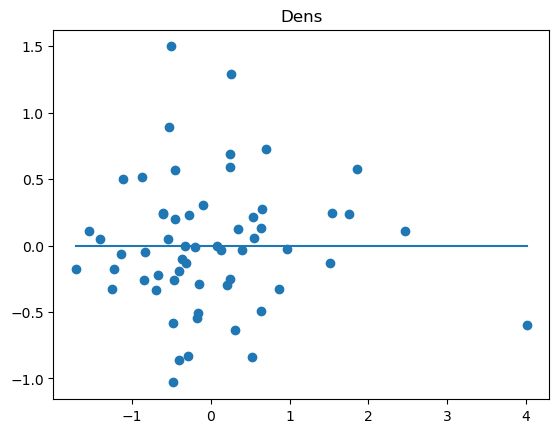

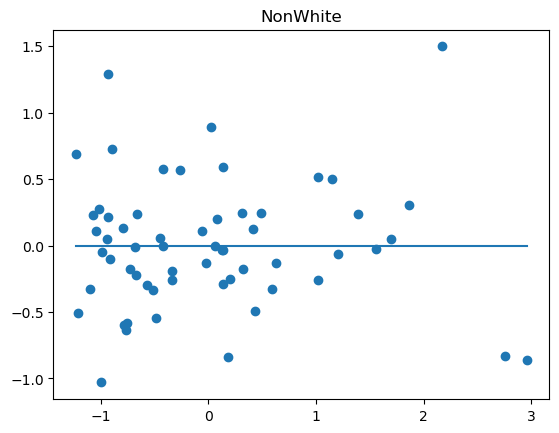

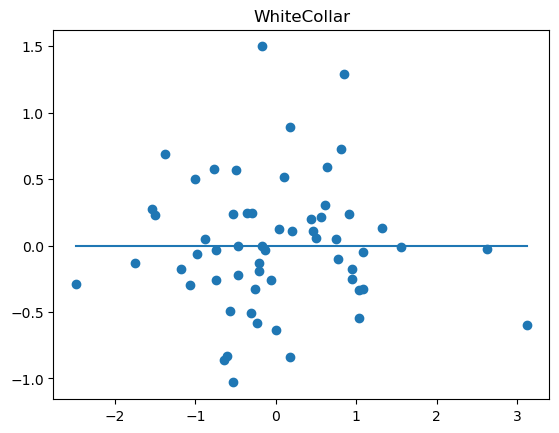

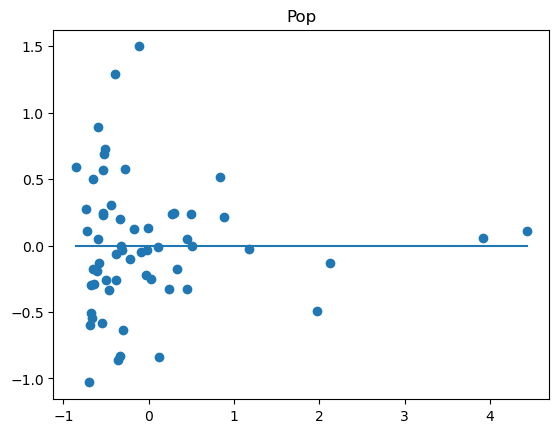

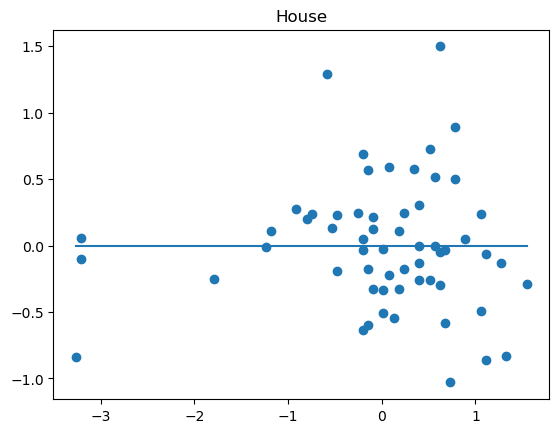

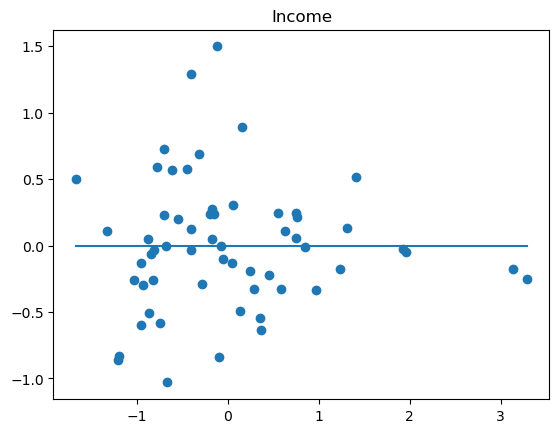

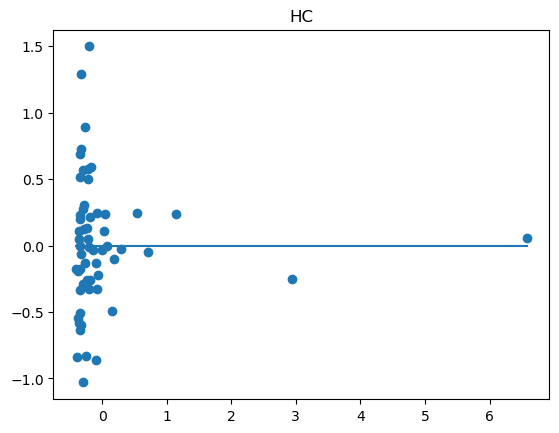

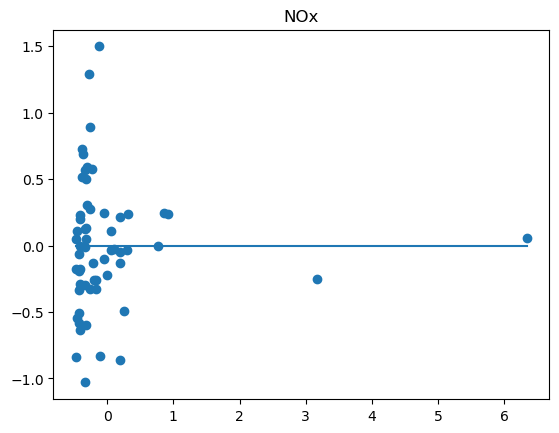

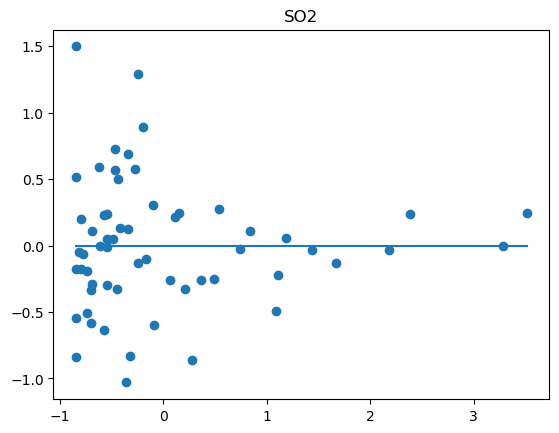

In [59]:
# Here we plot the residuals, so assess the quality of the fit
for i, f in enumerate([ f for f in m_fields if f != 'Mortality']):
  plt.plot(sorted(m_X_scaled.T[i]), np.zeros_like(m_Y_scaled))
  plt.scatter(m_X_scaled.T[i], m_Y_scaled - m_X_inter.dot(m_beta_gd))
  plt.title(f)
  plt.show()

BetaHat = [-2.08055795e-16 -3.32705679e-01 -3.98095912e-02  1.11896953e-02
  4.23207626e-01 -1.65684038e-01  1.98549144e-02  5.41098552e-01
 -1.32119965e-01  7.54583613e-02 -4.38555113e-02 -8.07251530e-02
 -2.73878255e-01  6.84244488e-01 -1.04588858e-01]
Final loss value = 15.390076964414632


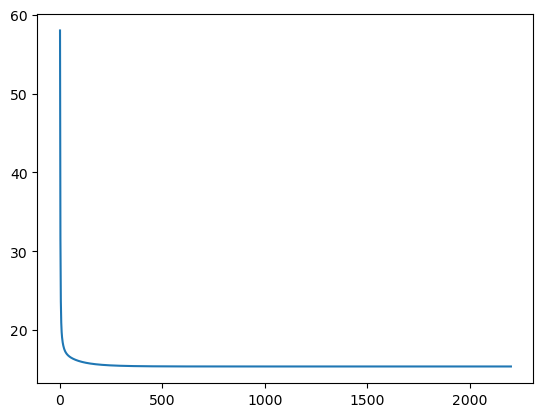

In [63]:
#From the residuals, and the Q-Q plots, we find the following variables deviate significantly from normality: ['NonWhite','Pop','HC','NOx','SO2']
# So we perform a log transform on the _non-scaled_ values

m_X_transformed = np.array([ m_values[f] if f not in ['NonWhite','Pop','HC','NOx','SO2'] else np.log(m_values[f]) for f in m_fields ]).T
m_X_transformed = m_X_transformed[:,1:] # (Feb 18) updated to exclude dependent variable "Mortality"

# After the transform, we then rescale all variables accroding to the new means and standard deviations
m_X_transformed_scaled = (m_X_transformed - m_X_transformed.mean(axis=0))/m_X_transformed.std(axis=0, ddof=1)
m_X_ts_inter = add_intercept(m_X_transformed_scaled) 
# Then perform the gradient descent again
m_beta_gd, m_losses = gradient_descent(m_X_ts_inter, m_Y_scaled, 0.001, 1e-6, max_iter=100000)
print("BetaHat = {}".format(m_beta_gd))
print("Final loss value = {}".format(m_losses[-1]))
plt.plot(range(len(m_losses)), m_losses)
plt.show()

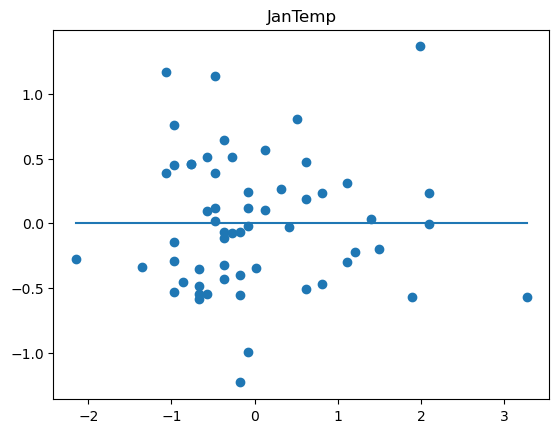

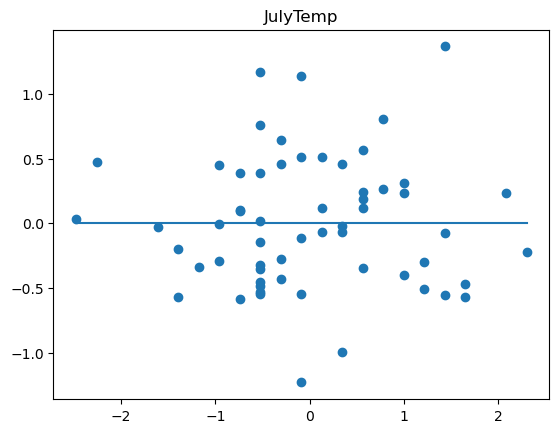

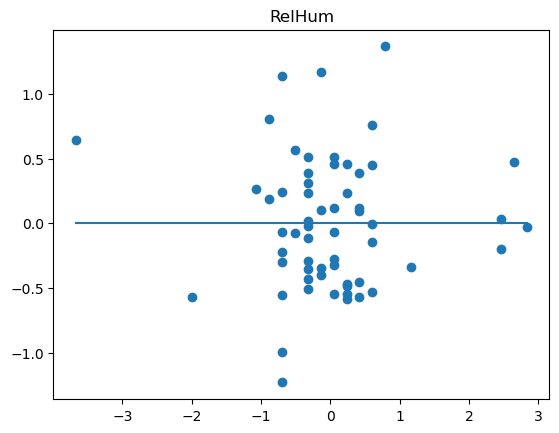

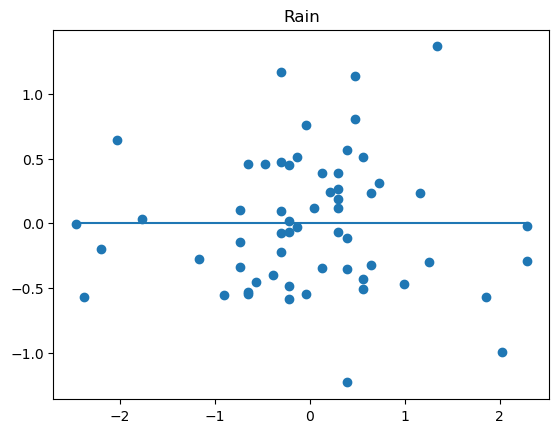

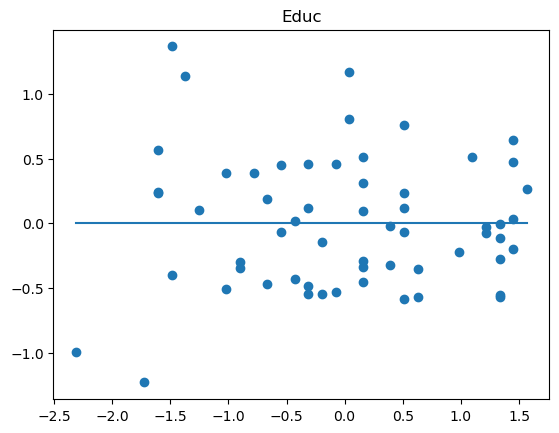

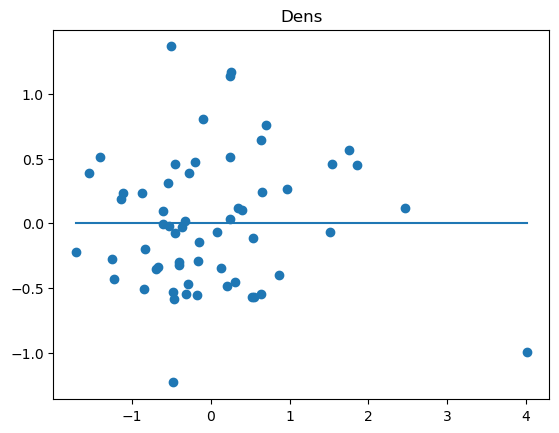

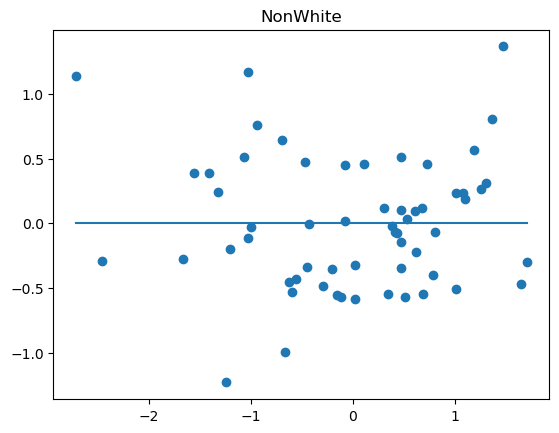

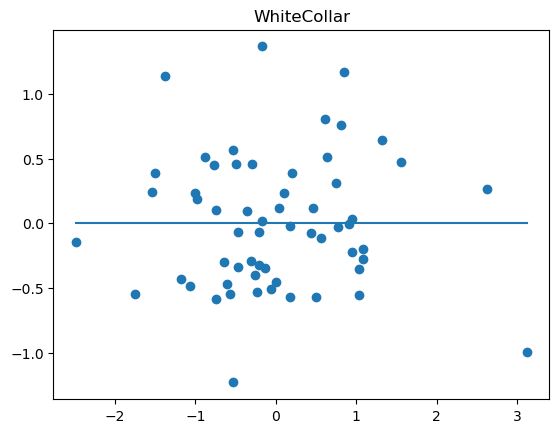

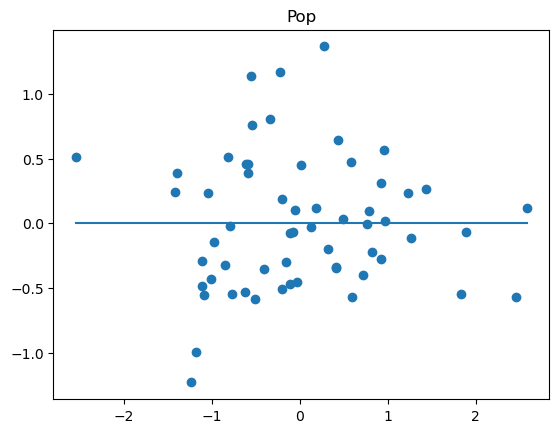

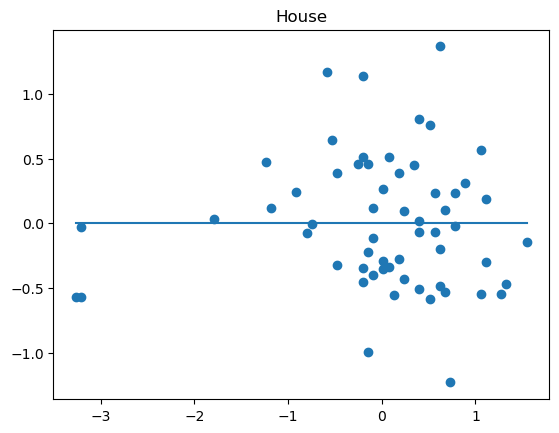

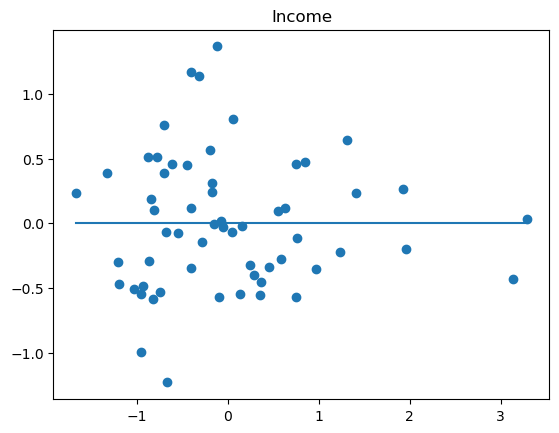

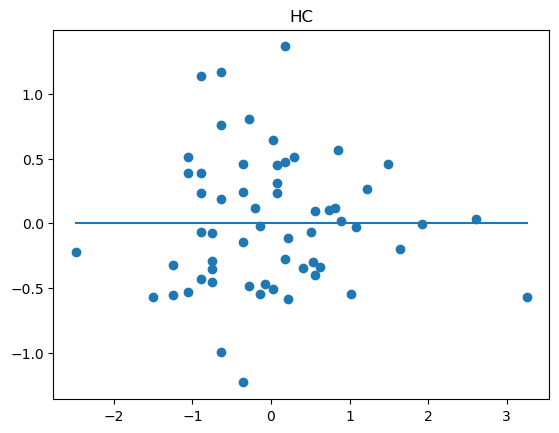

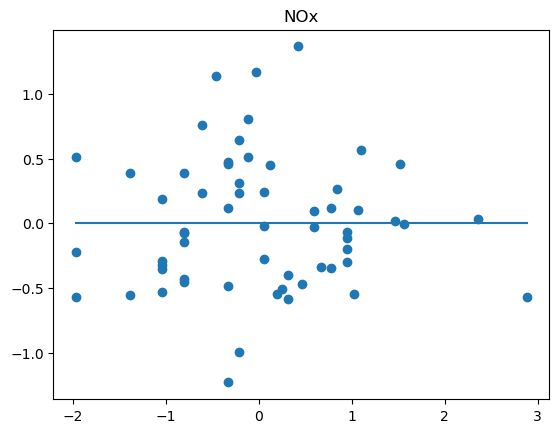

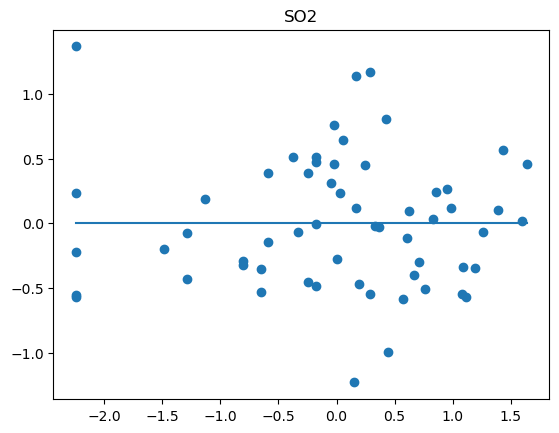

In [65]:
# We can also plot the residuals again, and we see that they are also improved.
for i, f in enumerate([ f for f in m_fields if f != 'Mortality']):
  plt.plot(sorted(m_X_transformed_scaled.T[i]), np.zeros_like(m_Y_scaled))
  plt.scatter(m_X_transformed_scaled.T[i], m_Y_scaled - m_X_ts_inter.dot(m_beta_gd))
  plt.title(f)
  plt.show()